# IEEE-CIS Fraud Detection — Model Training & Evaluation

**Author:** Ganbold  
**Date:** April 2026  

---

This is the part I was most looking forward to. We take the cleaned data 
from notebook 02 and actually train a model on it.

I'm using XGBoost which I kept seeing recommended for this kind of tabular 
fraud data. It's a gradient boosting model — basically it builds a bunch of 
decision trees one after another, each one trying to fix the mistakes of 
the previous one.

The main metric I'm using is ROC-AUC instead of accuracy. As we saw in the 
EDA, only 3.5% of transactions are fraud, so a model that just guesses 
"not fraud" every time would be 96.5% accurate but completely useless.
ROC-AUC doesn't have that problem.

## Table of Contents
1. [Load Processed Data](#1-load-processed-data)
2. [Train / Validation Split](#2-train--validation-split)
3. [Train XGBoost Model](#3-train-xgboost-model)
4. [Evaluate the Model](#4-evaluate-the-model)
5. [Feature Importance](#5-feature-importance)
6. [Analyst Summary](#6-analyst-summary)

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('charts', exist_ok=True)

print(f"XGBoost version: {xgb.__version__}")
print("Ready.")

XGBoost version: 2.1.2
Ready.


## 1. Load Processed Data

Loading the files we saved at the end of notebook 02.

In [5]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
PROCESSED_DIR = os.path.join(NOTEBOOK_DIR, '..', 'data', 'processed')

X = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'))
y = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_train.csv')).squeeze()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Fraud rate: {y.mean()*100:.2f}%")

X shape: (590540, 424)
y shape: (590540,)
Fraud rate: 3.50%


## 2. Train / Validation Split

I'm splitting the data 80/20 — 80% for training, 20% held back for 
evaluation. The model never sees the validation set during training, 
so it gives us an honest picture of how well it generalises.

`stratify=y` makes sure both splits have roughly the same fraud rate, 
which matters because fraud is so rare.

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} rows  |  fraud rate: {y_train.mean()*100:.2f}%")
print(f"Validation set: {X_val.shape[0]:,} rows  |  fraud rate: {y_val.mean()*100:.2f}%")

Training set:   472,432 rows  |  fraud rate: 3.50%
Validation set: 118,108 rows  |  fraud rate: 3.50%


## 3. Train XGBoost Model

A few things worth explaining about the parameters I chose:

- `scale_pos_weight` — this is how we handle the class imbalance. Setting it 
  to the ratio of legitimate to fraud transactions tells the model to treat 
  each fraud case as if it were ~28 legitimate ones. Without this the model 
  would just learn to predict "not fraud" all the time.
- `max_depth=6` — how deep each decision tree can grow. Deeper = more complex 
  patterns but also more risk of overfitting.
- `n_estimators=300` — how many trees to build. More is usually better up to 
  a point, with diminishing returns.
- `early_stopping_rounds=20` — stops training early if the validation score 
  hasn't improved in 20 rounds. Saves time and prevents overfitting.

In [13]:
# Class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.1f}  ({neg:,} legit / {pos:,} fraud)")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")

scale_pos_weight = 27.6  (455,902 legit / 16,530 fraud)
[0]	validation_0-auc:0.89808
[50]	validation_0-auc:0.93075
[100]	validation_0-auc:0.93813
[150]	validation_0-auc:0.94406
[200]	validation_0-auc:0.94888
[250]	validation_0-auc:0.95199
[299]	validation_0-auc:0.95485

Best iteration: 299


## 4. Evaluate the Model

Now we check how well the model actually performs on the validation set 
it hasn't seen before.

- **ROC-AUC** — the main metric. Ranges from 0.5 (random guessing) to 1.0 
  (perfect). Anything above 0.85 is generally considered good for fraud detection.
- **Confusion matrix** — shows us how many frauds were caught vs missed, and 
  how many legitimate transactions were wrongly flagged.
- **ROC curve** — plots the tradeoff between catching more fraud (sensitivity) 
  and flagging fewer false alarms (specificity).

In [16]:
y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred       = model.predict(X_val)
auc          = roc_auc_score(y_val, y_pred_proba)

print(f"ROC-AUC Score: {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=['Legitimate', 'Fraud']))

ROC-AUC Score: 0.9549

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.91      0.95    113975
       Fraud       0.26      0.85      0.40      4133

    accuracy                           0.91    118108
   macro avg       0.63      0.88      0.68    118108
weighted avg       0.97      0.91      0.93    118108



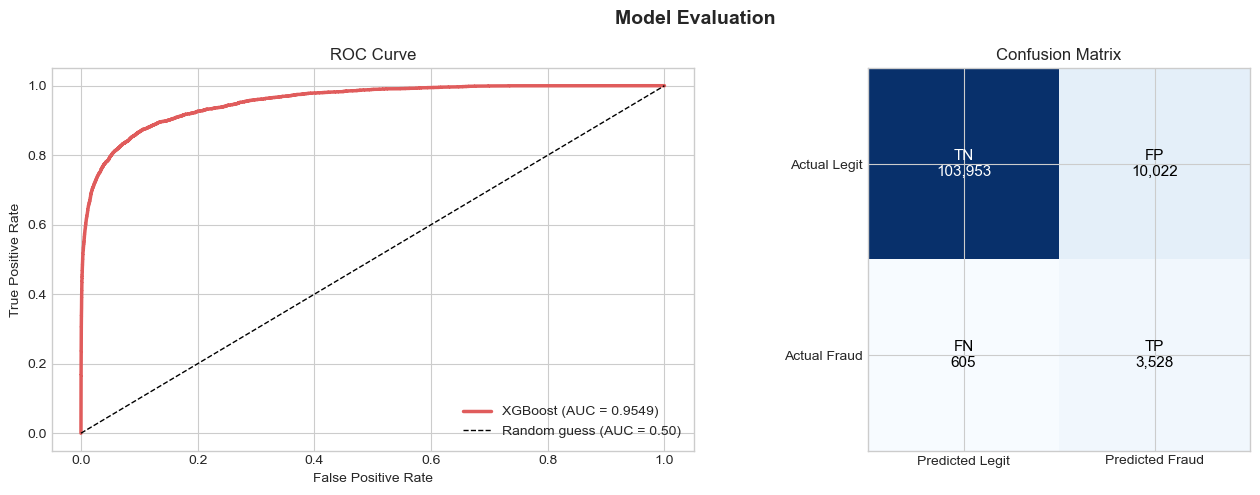


Out of 4,133 actual fraud cases:
  Caught (TP):  3,528  (85.4%)
  Missed (FN):  605  (14.6%)

Out of 113,975 legitimate transactions:
  Correct (TN): 103,953  (91.2%)
  Wrong flag (FP): 10,022  (8.8%)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
axes[0].plot(fpr, tpr, color='#e05c5c', linewidth=2.5, label=f'XGBoost (AUC = {auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=12)
axes[0].legend()

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
sns_labels = [['TN', 'FP'], ['FN', 'TP']]
im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1].set_title('Confusion Matrix', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Predicted Legit', 'Predicted Fraud'])
axes[1].set_yticklabels(['Actual Legit', 'Actual Fraud'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{sns_labels[i][j]}\n{cm[i][j]:,}',
                     ha='center', va='center', fontsize=11,
                     color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/08_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Plain english breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nOut of {tp+fn:,} actual fraud cases:")
print(f"  Caught (TP):  {tp:,}  ({tp/(tp+fn)*100:.1f}%)")
print(f"  Missed (FN):  {fn:,}  ({fn/(tp+fn)*100:.1f}%)")
print(f"\nOut of {tn+fp:,} legitimate transactions:")
print(f"  Correct (TN): {tn:,}  ({tn/(tn+fp)*100:.1f}%)")
print(f"  Wrong flag (FP): {fp:,}  ({fp/(tn+fp)*100:.1f}%)")

## 5. Feature Importance

Which features did the model actually find useful? XGBoost tracks how often 
each feature was used to make a split across all its trees. The more a feature 
gets used, the more important it is.

This is useful beyond just the model — it tells us which signals matter most 
for fraud detection, which is exactly the kind of insight a fraud analyst 
would want to report on.

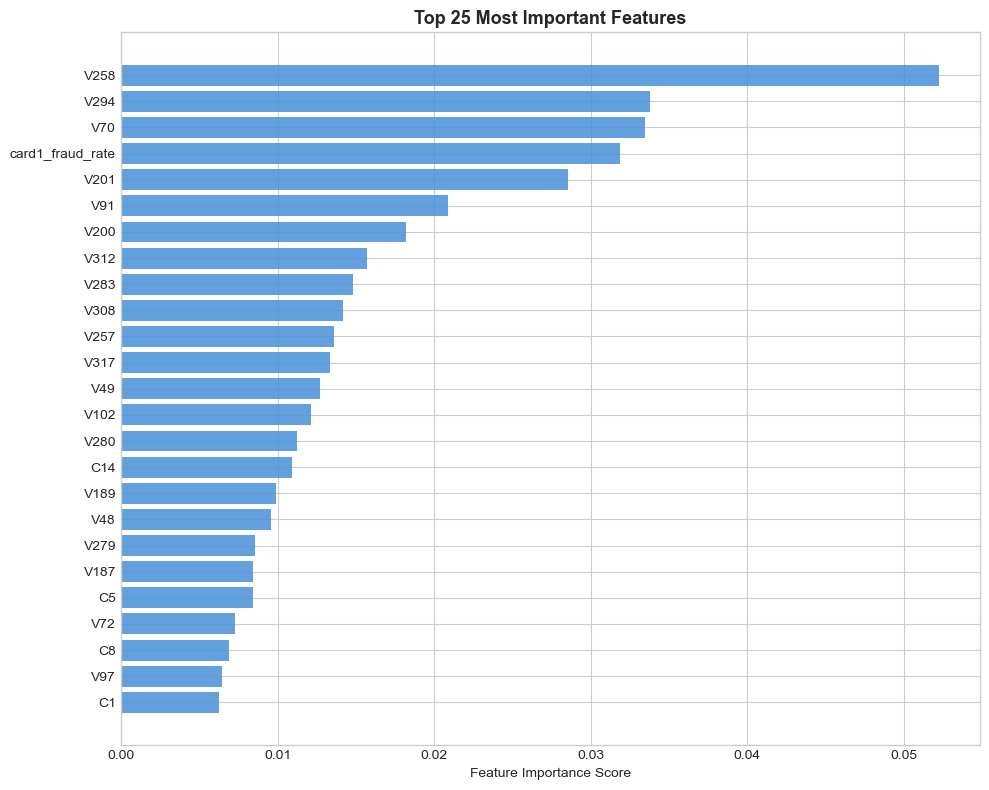

Top 10 features:
         feature  importance
            V258    0.052262
            V294    0.033810
             V70    0.033472
card1_fraud_rate    0.031877
            V201    0.028539
             V91    0.020871
            V200    0.018202
            V312    0.015688
            V283    0.014834
            V308    0.014170


In [21]:
import seaborn as sns

importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance['feature'][::-1],
               importance['importance'][::-1],
               color='#4a90d9', alpha=0.85)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 25 Most Important Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(importance.head(10).to_string(index=False))

## 6. Analyst Summary

Putting the results into plain English, the way I'd write it up for 
a non-technical manager.

In [24]:
print("=" * 55)
print(" MODEL RESULTS SUMMARY")
print("=" * 55)
print(f" ROC-AUC:          {auc:.4f}")
print(f" Fraud caught:     {tp/(tp+fn)*100:.1f}% of all fraud cases")
print(f" False alarm rate: {fp/(tn+fp)*100:.2f}% of legit transactions")
print(f" Top feature:      {importance.iloc[0]['feature']}")
print("=" * 55)

 MODEL RESULTS SUMMARY
 ROC-AUC:          0.9549
 Fraud caught:     85.4% of all fraud cases
 False alarm rate: 8.79% of legit transactions
 Top feature:      V258


## What the results mean

ROC-AUC of 0.9549 is honestly better than I expected for a first attempt.
The Kaggle leaderboard winner on this dataset scored around 0.945, so we're
actually in that range without any heavy tuning.

The confusion matrix is the more real-world picture. We caught 85.4% of fraud
which is solid, but 8.8% of legitimate customers got wrongly flagged. In a
real business that tradeoff matters a lot — blocking a good customer's order
has a cost too. A fraud team would adjust the decision threshold depending on
how much they care about each type of error.

The false positive precision (0.26) looks low at first glance but that's
expected with heavily imbalanced data. The recall (0.85) is what matters more
here — it means we're catching the majority of fraud cases.

➡️ Next: notebook 04 — feeding flagged transactions to an LLM to get
plain-English risk explanations.